         x   y   z      m
13007   31  31  31  0.125
52531   31  31  32  0.125
78537   31  32  32  0.125
125349  31  32  31  0.125
136796  32  32  31  0.125
183600  32  32  32  0.125
209610  32  31  32  0.125
249142  32  31  31  0.125
32768.0 (262144, 4)


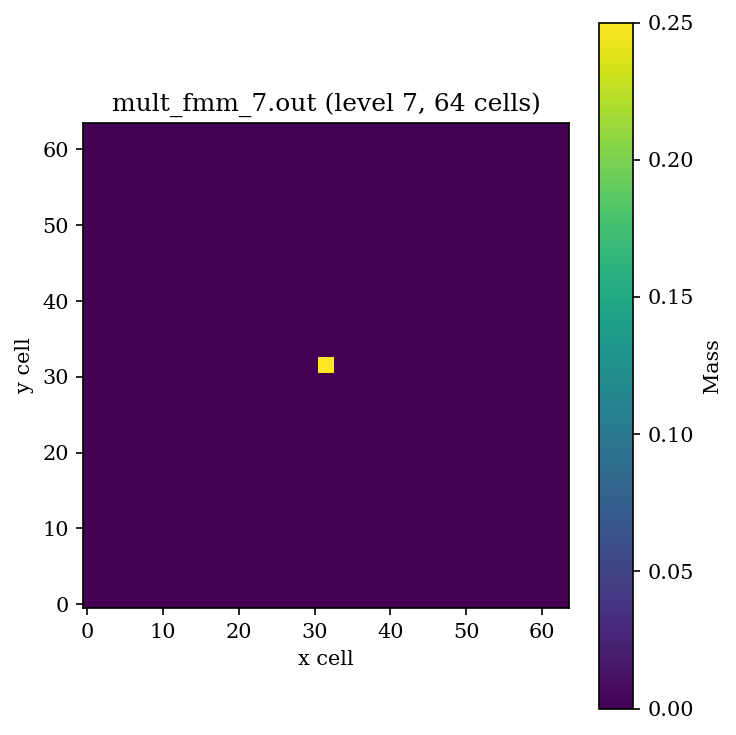

In [55]:
# -*- coding: utf-8 -*-
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({"font.size": 10})

# -------------------------------
# Parameters
# -------------------------------
out_dir = "../out"
filenames = [f"mult_fmm_{i}.out" for i in range(7, 8)]
names = ["x", "y", "z", "m"]  # only mass

# -------------------------------
# Load particle data
# -------------------------------
def load_data(filename, out_dir="../out"):
    file_path = os.path.join(out_dir, filename)
    df = pd.read_csv(file_path, header=None, sep=r"\s+", names=names)
    # shift min to zero
    df["x"] -= df["x"].min()
    df["y"] -= df["y"].min()
    df["z"] -= df["z"].min()
    return df

# -------------------------------
# Bin mass into 2D histogram along z
# -------------------------------
def bin_mass_2d(df, N_cells):
    # define grid edges from min to max x/y
    x_edges = np.linspace(df["x"].min(), df["x"].max(), N_cells+1)
    y_edges = np.linspace(df["y"].min(), df["y"].max(), N_cells+1)

    # histogram 2D: sum mass along z into x-y
    mass_grid, _, _ = np.histogram2d(df["y"], df["x"], bins=[y_edges, x_edges], weights=df["m"])
    return mass_grid

# -------------------------------
# Plot 2D mass grid
# -------------------------------
def plot_mass_grid(mass_grid, title=None):
    plt.figure(figsize=(5,5))
    plt.imshow(mass_grid, origin="lower", cmap="viridis")
    plt.colorbar(label="Mass")
    plt.title(title)
    plt.xlabel("x cell")
    plt.ylabel("y cell")
    plt.tight_layout()
    plt.show()

# -------------------------------
# Loop over files
# -------------------------------
for fname in filenames:
    # determine N_cells from level in filename
    level = int(re.search(r"mult_fmm_(\d+)", fname).group(1))
    N_cells = 2 ** (level-1)

    df = load_data(fname, out_dir)
    print(df[df['m']>0])
    print(N_cells**3/8, df.shape) 
    mass_grid = bin_mass_2d(df, N_cells)
    plot_mass_grid(mass_grid, title=f"{fname} (level {level}, {N_cells} cells)")


Empty DataFrame
Columns: [x, y, z, m]
Index: []


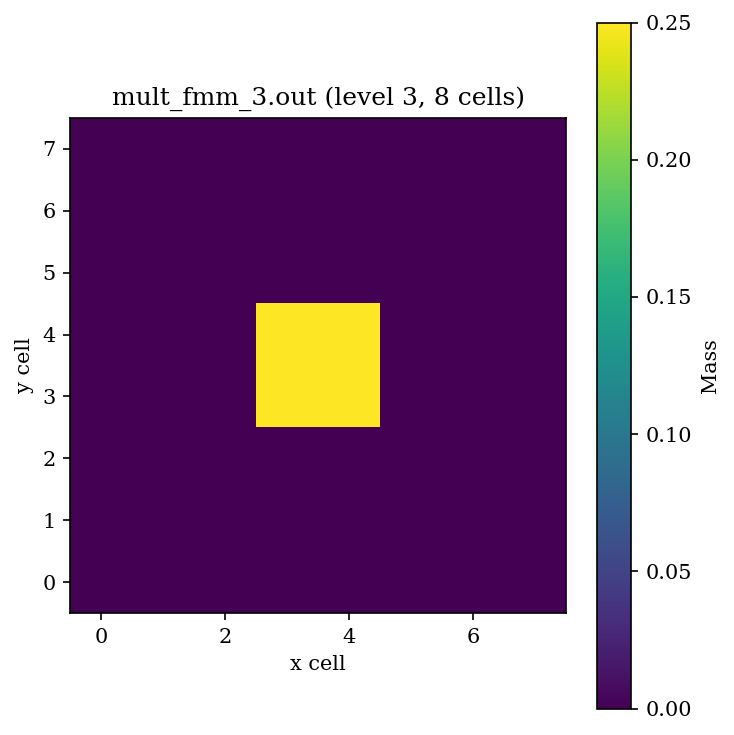

Empty DataFrame
Columns: [x, y, z, m]
Index: []


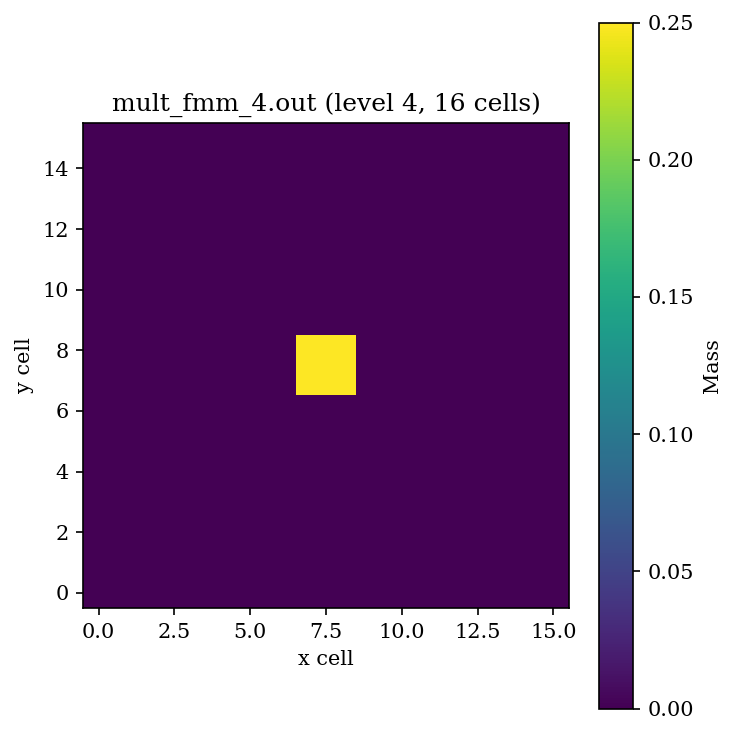

Empty DataFrame
Columns: [x, y, z, m]
Index: []


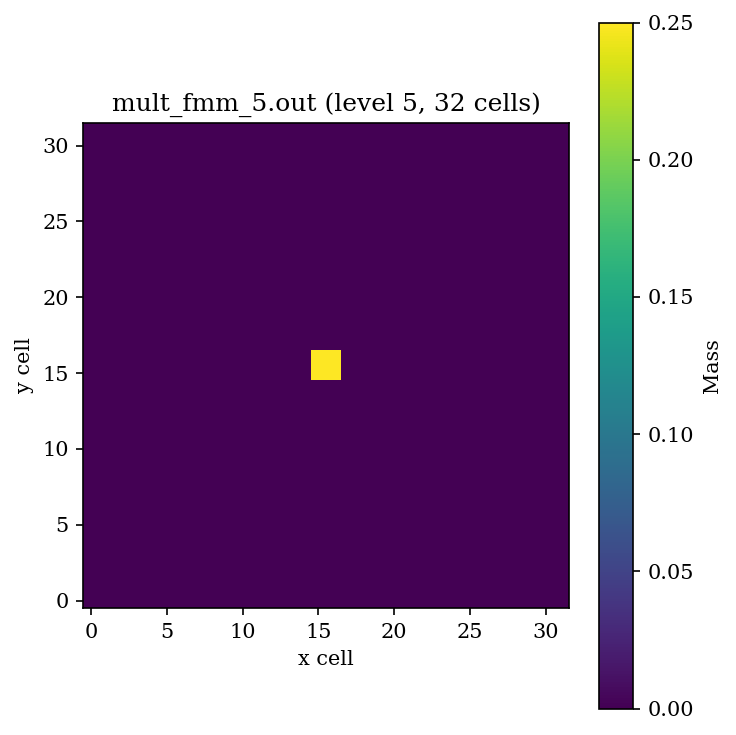

Empty DataFrame
Columns: [x, y, z, m]
Index: []


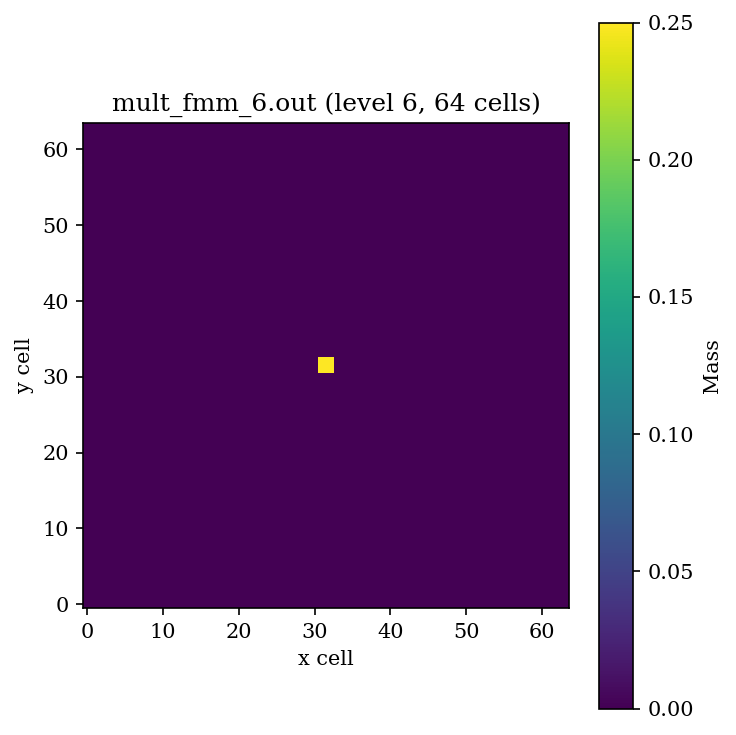

In [42]:
# -------------------------------
# Loop over files
# -------------------------------
for fname in filenames:
    # determine N_cells from level in filename
    level = int(re.search(r"mult_fmm_(\d+)", fname).group(1))
    N_cells = 2 ** level

    df = load_data(fname, out_dir)
    print(df[df['m']<0])
    mass_grid = bin_mass_2d(df, N_cells)
    plot_mass_grid(mass_grid, title=f"{fname} (level {level}, {N_cells} cells)")